In [1]:
import sys
import numpy as np
import cv2
import sklearn
import scipy
from tqdm import tqdm

print(sys.executable)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("sklearn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("tqdm working")

C:\Users\chshe\palm_fixed\Scripts\python.exe
NumPy: 1.26.4
OpenCV: 4.10.0
sklearn: 1.3.2
SciPy: 1.11.4
tqdm working


In [2]:
print("Project started successfully")

Project started successfully


In [3]:
!pip install numpy opencv-python matplotlib tqdm

In [3]:
!pip install numpy

In [20]:
import sys
!{sys.executable} -m pip install numpy==1.26.4 --force-reinstall

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\chshe\\palm_tf\\Lib\\site-packages\\~-mpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll'
Check the permissions.

You should consider upgrading via the 'C:\Users\chshe\palm_tf\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
%pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\chshe\palm_tf\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

print("All imports working")
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

All imports working
NumPy: 1.26.4
OpenCV: 4.10.0


In [4]:
import os

dataset_path = "dataset"

# list folders inside dataset
folders = os.listdir(dataset_path)

print("Folders inside dataset:")
print(folders)

Folders inside dataset:
['README.md', 'test', 'train']


In [5]:
train_path = "dataset/train"

train_folders = os.listdir(train_path)

print("Train categories:")
print(train_folders)

Train categories:
['images', 'labels']


In [6]:
train_images_path = "dataset/train/images"

train_images_folders = os.listdir(train_images_path)

print("Inside train/images:")
print(train_images_folders[:10])

Inside train/images:
['.gitkeep', 'image0.tif', 'image1.tif', 'image10.tif', 'image100.tif', 'image1000.tif', 'image1001.tif', 'image1002.tif', 'image1003.tif', 'image1004.tif']


(-0.5, 255.5, 255.5, -0.5)

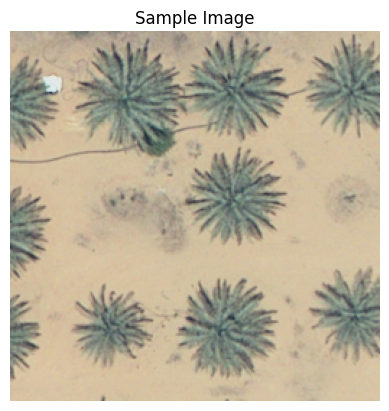

In [7]:
import cv2
import matplotlib.pyplot as plt

# pick first image (skip .gitkeep)
image_path = "dataset/train/images/image0.tif"

img = cv2.imread(image_path)

# convert BGR → RGB (IMPORTANT)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# show image
plt.imshow(img_rgb)
plt.title("Sample Image")
plt.axis("off")

In [8]:
print("Original image shape:", img_rgb.shape)

Original image shape: (256, 256, 3)


In [9]:
import numpy as np

def convert_to_hyperspectral_cube(img_rgb):
    # convert image to float values between 0 and 1
    img = img_rgb.astype(np.float32) / 255.0

    # original RGB bands
    band1 = img[:, :, 0]   # Red
    band2 = img[:, :, 1]   # Green
    band3 = img[:, :, 2]   # Blue

    # generated additional spectral bands
    band4 = (band1 + band2) / 2
    band5 = (band2 + band3) / 2
    band6 = (band1 + band3) / 2
    band7 = 0.6 * band1 + 0.4 * band2
    band8 = 0.6 * band2 + 0.4 * band3
    band9 = 0.6 * band1 + 0.4 * band3
    band10 = (band1 + band2 + band3) / 3

    # stack all bands into one cube
    hyperspectral_cube = np.stack([
        band1, band2, band3,
        band4, band5, band6,
        band7, band8, band9,
        band10
    ], axis=-1)

    return hyperspectral_cube

In [10]:
hsi_cube = convert_to_hyperspectral_cube(img_rgb)

print("Hyperspectral cube shape:", hsi_cube.shape)

Hyperspectral cube shape: (256, 256, 10)


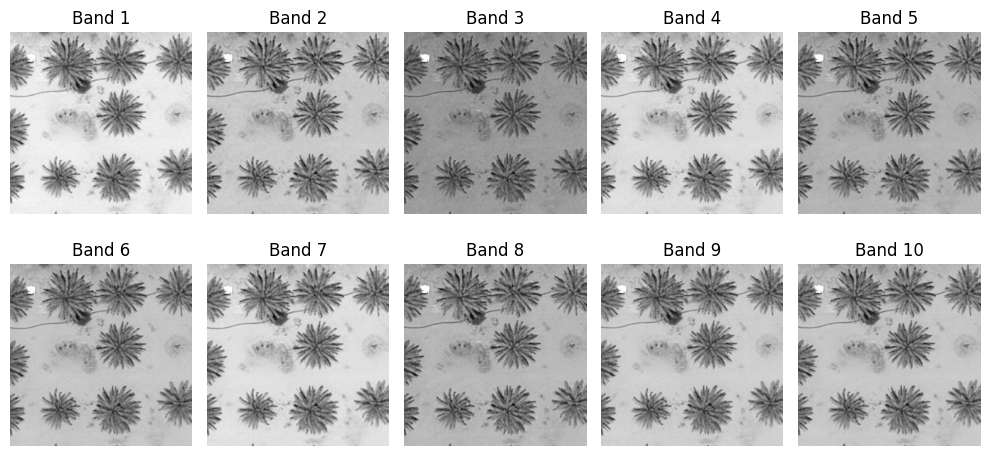

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(hsi_cube[:,:,i], cmap='gray')
    plt.title(f'Band {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
hsi_cube = hsi_cube / hsi_cube.max()

In [13]:
print("Min:", hsi_cube.min())
print("Max:", hsi_cube.max())

Min: 0.11158799
Max: 1.0


In [14]:

import os

train_images_path = "Dataset/train/images"
train_labels_path = "Dataset/train/labels"
test_images_path = "Dataset/test/images"
test_labels_path = "Dataset/test/labels"

print("Train images sample:", os.listdir(train_images_path)[:10])
print("Train labels sample:", os.listdir(train_labels_path)[:10])
print("Test images sample:", os.listdir(test_images_path)[:10])
print("Test labels sample:", os.listdir(test_labels_path)[:10])
 

Train images sample: ['.gitkeep', 'image0.tif', 'image1.tif', 'image10.tif', 'image100.tif', 'image1000.tif', 'image1001.tif', 'image1002.tif', 'image1003.tif', 'image1004.tif']
Train labels sample: ['.gitkeep', 'image0.xml', 'image1.xml', 'image10.xml', 'image100.xml', 'image1000.xml', 'image1002.xml', 'image1003.xml', 'image1005.xml', 'image1006.xml']
Test images sample: ['.gitkeep']
Test labels sample: ['.gitkeep']


In [15]:
import os
import xml.etree.ElementTree as ET

train_images_path = "Dataset/train/images"
train_labels_path = "Dataset/train/labels"

class_names = []

for xml_file in os.listdir(train_labels_path):
    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(train_labels_path, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name")
        if name is not None:
            class_names.append(name.text)

print("Sample class names:", class_names[:20])
print("Unique classes:", sorted(set(class_names)))
print("Number of unique classes:", len(set(class_names)))

Sample class names: ['palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree', 'palmtree']
Unique classes: ['palmtree']
Number of unique classes: 1


Image file: image0.tif
Crop shape: (64, 33, 3)


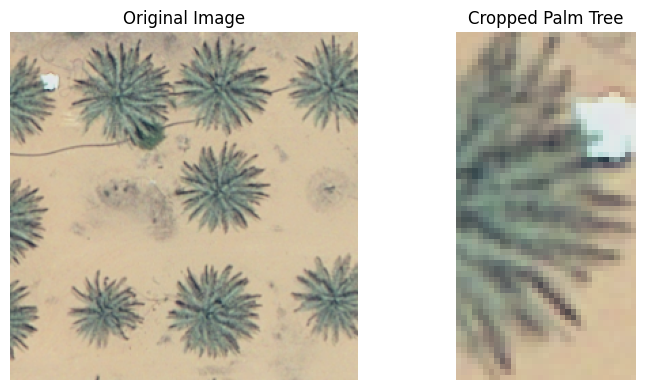

In [16]:
import os
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

train_images_path = "Dataset/train/images"
train_labels_path = "Dataset/train/labels"

# pick one xml file
xml_files = [f for f in os.listdir(train_labels_path) if f.endswith(".xml")]
xml_file = xml_files[0]

xml_path = os.path.join(train_labels_path, xml_file)

# matching image file
image_name = os.path.splitext(xml_file)[0] + ".tif"
image_path = os.path.join(train_images_path, image_name)

# read xml
tree = ET.parse(xml_path)
root = tree.getroot()

# read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# take first object
obj = root.find("object")
bndbox = obj.find("bndbox")

xmin = int(bndbox.find("xmin").text)
ymin = int(bndbox.find("ymin").text)
xmax = int(bndbox.find("xmax").text)
ymax = int(bndbox.find("ymax").text)

# crop palm tree region
crop = img_rgb[ymin:ymax, xmin:xmax]

print("Image file:", image_name)
print("Crop shape:", crop.shape)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop)
plt.title("Cropped Palm Tree")
plt.axis("off")

plt.tight_layout()
plt.show()
        

In [17]:
# resize crop (important for model later)
crop_resized = cv2.resize(crop, (128, 128))

# convert to hyperspectral cube
hsi_crop = convert_to_hyperspectral_cube(crop_resized)

# normalize
hsi_crop = hsi_crop / hsi_crop.max()

print("HSI crop shape:", hsi_crop.shape)

HSI crop shape: (128, 128, 10)


In [18]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

train_images_path = "Dataset/train/images"
train_labels_path = "Dataset/train/labels"

data = []
labels = []
class_map = {}

for xml_file in os.listdir(train_labels_path):
    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(train_labels_path, xml_file)

    # match image
    image_name = os.path.splitext(xml_file)[0] + ".tif"
    image_path = os.path.join(train_images_path, image_name)

    if not os.path.exists(image_path):
        continue

    # read image
    img = cv2.imread(image_path)
    if img is None:
        continue

    # parse xml
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")

        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        # crop
        crop = img[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        # resize
        crop = cv2.resize(crop, (128, 128))

        # hyperspectral
        hsi = convert_to_hyperspectral_cube(crop)

        if hsi.max() != 0:
            hsi = hsi / hsi.max()

        data.append(hsi)

        # label from XML object name
        label_name = obj.find("name").text.strip()

        if label_name not in class_map:
            class_map[label_name] = len(class_map)

        labels.append(class_map[label_name])

data = np.array(data, dtype=np.float32)
labels = np.array(labels)

print("Dataset shape:", data.shape)
print("Labels shape:", labels.shape)
print("Class map:", class_map)
print("Unique labels:", np.unique(labels))

Dataset shape: (9874, 128, 128, 10)
Labels shape: (9874,)
Class map: {'palmtree': 0}
Unique labels: [0]


In [19]:
print("Dataset shape:", data.shape)
print("Labels shape:", labels.shape)

Dataset shape: (9874, 128, 128, 10)
Labels shape: (9874,)


In [20]:
import os

print("Train images path:", train_images_path)
print("Train labels path:", train_labels_path)

print("\nFolders inside Dataset:")
print(os.listdir("Dataset"))

print("\nFolders inside Dataset/train:")
print(os.listdir("Dataset/train"))

Train images path: Dataset/train/images
Train labels path: Dataset/train/labels

Folders inside Dataset:
['README.md', 'test', 'train']

Folders inside Dataset/train:
['images', 'labels']


In [21]:
import os

print("First 20 train image files:")
train_files = sorted(os.listdir("Dataset/train/images"))
print(train_files[:20])

First 20 train image files:
['.gitkeep', 'image0.tif', 'image1.tif', 'image10.tif', 'image100.tif', 'image1000.tif', 'image1001.tif', 'image1002.tif', 'image1003.tif', 'image1004.tif', 'image1005.tif', 'image1006.tif', 'image1007.tif', 'image1008.tif', 'image1009.tif', 'image101.tif', 'image1010.tif', 'image1011.tif', 'image1012.tif', 'image1013.tif']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (7899, 128, 128, 10)
Validation: (1975, 128, 128, 10)


In [24]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Train: (7899, 128, 128, 10)
Validation: (1975, 128, 128, 10)
y_train: (7899,)
y_val: (1975,)


In [25]:
X_train = X_train / 255.0
X_val = X_val / 255.0

In [26]:
print(X_train.min(), X_train.max())

0.0 0.003921569


In [27]:
import sys
print(sys.executable)

C:\Users\chshe\palm_fixed\Scripts\python.exe


In [28]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [29]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (7899, 128, 128, 10)
y_train shape: (7899,)
X_val shape: (1975, 128, 128, 10)
y_val shape: (1975,)


In [30]:
import numpy as np

print("Before fix:")
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val   min/max:", X_val.min(), X_val.max())

# If values are too tiny, undo the extra /255
if X_train.max() <= 0.01 and X_val.max() <= 0.01:
    X_train = X_train * 255.0
    X_val = X_val * 255.0
    print("\nExtra division by 255 detected -> fixed.")
else:
    print("\nNormalization looks fine already.")

# Final safe dtype
X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

print("\nAfter fix:")
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val   min/max:", X_val.min(), X_val.max())

Before fix:
X_train min/max: 0.0 0.003921569
X_val   min/max: 0.00018239854 0.003921569

Extra division by 255 detected -> fixed.

After fix:
X_train min/max: 0.0 1.0
X_val   min/max: 0.046511628 1.0


In [31]:
classes = np.unique(y_train)
num_classes = len(classes)

print("Unique classes in y_train:", classes)
print("Number of classes:", num_classes)
print("y_train dtype:", y_train.dtype)

Unique classes in y_train: [0]
Number of classes: 1
y_train dtype: int32


In [33]:

import numpy as np

labels = []

for sample in data:
    mean_intensity = np.mean(sample)

    if mean_intensity > 0.5:
        labels.append(1)   # brighter canopy
    else:
        labels.append(0)   # darker canopy

labels = np.array(labels, dtype=np.int32)

print("Unique labels:", np.unique(labels))
print("Label distribution:", np.bincount(labels))
print("Labels shape:", labels.shape)

Unique labels: [0 1]
Label distribution: [1033 8841]
Labels shape: (9874,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("Train classes:", np.unique(y_train))
print("Val classes:", np.unique(y_val))

X_train shape: (7899, 128, 128, 10)
y_train shape: (7899,)
X_val shape: (1975, 128, 128, 10)
y_val shape: (1975,)
Train classes: [0 1]
Val classes: [0 1]


In [35]:
classes = np.unique(y_train)
num_classes = len(classes)

print("Unique classes in y_train:", classes)
print("Number of classes:", num_classes)
print("y_train dtype:", y_train.dtype)

Unique classes in y_train: [0 1]
Number of classes: 2
y_train dtype: int32


In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      2912      
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 32, 32, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 128)     

In [37]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10


247/247 [==============================] - 57s 224ms/step - loss: 0.2031 - accuracy: 0.9186 - val_loss: 0.1120 - val_accuracy: 0.9473
Epoch 2/10
247/247 [==============================] - 43s 176ms/step - loss: 0.1164 - accuracy: 0.9472 - val_loss: 0.1276 - val_accuracy: 0.9327
Epoch 3/10
247/247 [==============================] - 42s 172ms/step - loss: 0.1067 - accuracy: 0.9532 - val_loss: 0.1854 - val_accuracy: 0.9154
Epoch 4/10
247/247 [==============================] - 41s 167ms/step - loss: 0.0913 - accuracy: 0.9585 - val_loss: 0.0781 - val_accuracy: 0.9651
Epoch 5/10
247/247 [==============================] - 41s 166ms/step - loss: 0.0674 - accuracy: 0.9725 - val_loss: 0.0747 - val_accuracy: 0.9641
Epoch 6/10
247/247 [==============================] - 41s 165ms/step - loss: 0.0863 - accuracy: 0.9620 - val_loss: 0.0682 - val_accuracy: 0.9671
Epoch 7/10
247/247 [==============================] - 43s 175ms/step - loss: 0.0831 - accuracy: 0.9634 - val_loss: 0.1434 - val_

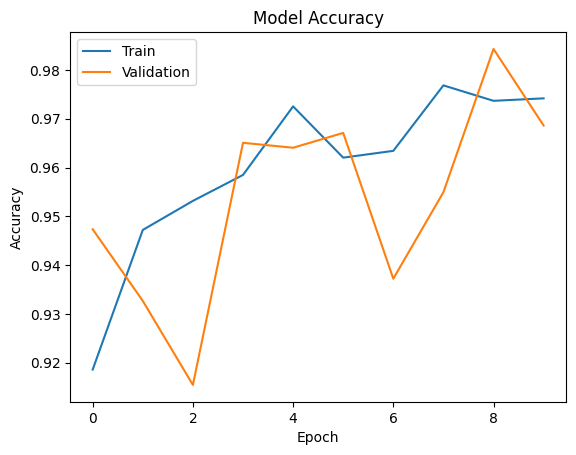

In [38]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

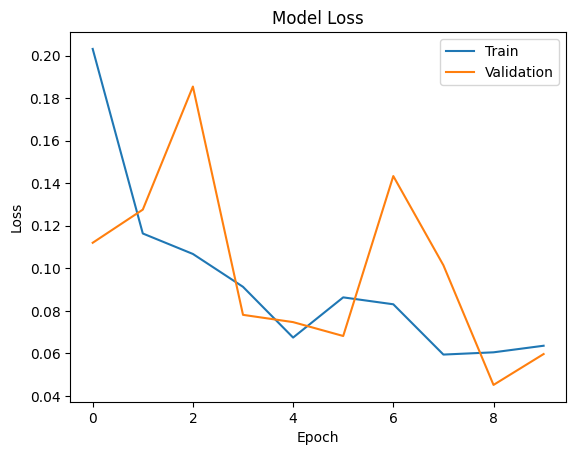

In [39]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [40]:
y_pred = model.predict(X_val)
y_pred = (y_pred > 0.5).astype(int)

62/62 [==============================] - 3s 40ms/step


In [41]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

Confusion Matrix:
 [[ 147   60]
 [   2 1766]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.71      0.83       207
           1       0.97      1.00      0.98      1768

    accuracy                           0.97      1975
   macro avg       0.98      0.85      0.90      1975
weighted avg       0.97      0.97      0.97      1975



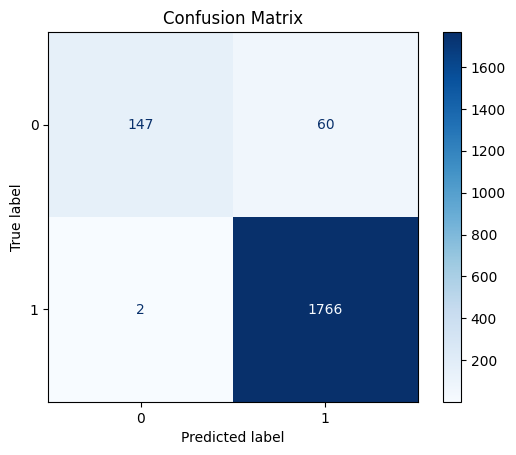

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [44]:
!pip install pandas

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.1 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/11.3 MB 5.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.3 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 13.8 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 13.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [pytz]
   ---------------------------------------- 0/2 [pytz]
   ---------------------------------------- 0/2 [pytz]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   --------------------

In [45]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'Value': [
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred, average='weighted'),
        recall_score(y_val, y_pred, average='weighted'),
        f1_score(y_val, y_pred, average='weighted')
    ]
})

print(results_df)

                 Metric     Value
0              Accuracy  0.968608
1  Precision (Weighted)  0.969178
2     Recall (Weighted)  0.968608
3   F1-Score (Weighted)  0.966304


In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

def create_transformer_model():
    inputs = layers.Input(shape=input_shape)

    # Flatten spatial dims into patches
    x = layers.Reshape((128*128, 10))(inputs)

    # Projection
    x = layers.Dense(64)(x)

    # Transformer block
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(128, activation='relu')(x)
    ffn = layers.Dense(64)(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization()(x)

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

transformer_model = create_transformer_model()
transformer_model.summary(

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 10)]       0         []                            
                                                                                                  
 reshape (Reshape)           (None, 16384, 10)            0         ['input_2[0][0]']             
                                                                                                  
 dense_2 (Dense)             (None, 16384, 64)            704       ['reshape[0][0]']             
                                                                                                  
 multi_head_attention (Mult  (None, 16384, 64)            66368     ['dense_2[0][0]',             
 iHeadAttention)                                                     'dense_2[0][0]']         

In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

def create_small_transformer():
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, (4, 4), strides=(4, 4), padding='same')(inputs)   # downsample
    x = layers.Reshape((32 * 32, 16))(x)  # much fewer tokens than before

    x_proj = layers.Dense(32)(x)

    attention = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x_proj, x_proj)
    x = layers.Add()([x_proj, attention])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(64, activation='relu')(x)
    ffn = layers.Dense(32)(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

small_transformer_model = create_small_transformer()
small_transformer_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 128, 128, 10)]       0         []                            
                                                                                                  
 conv2d_3 (Conv2D)           (None, 32, 32, 16)           2576      ['input_3[0][0]']             
                                                                                                  
 reshape_1 (Reshape)         (None, 1024, 16)             0         ['conv2d_3[0][0]']            
                                                                                                  
 dense_7 (Dense)             (None, 1024, 32)             544       ['reshape_1[0][0]']           
                                                                                            

In [50]:
history_small_transformer = small_transformer_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/10
494/494 [==============================] - 153s 297ms/step - loss: 0.2862 - accuracy: 0.9032 - val_loss: 0.1061 - val_accuracy: 0.9423
Epoch 2/10
494/494 [==============================] - 133s 269ms/step - loss: 0.1019 - accuracy: 0.9558 - val_loss: 0.0627 - val_accuracy: 0.9757
Epoch 3/10
494/494 [==============================] - 132s 266ms/step - loss: 0.0953 - accuracy: 0.9582 - val_loss: 0.0853 - val_accuracy: 0.9610
Epoch 4/10
494/494 [==============================] - 133s 269ms/step - loss: 0.0933 - accuracy: 0.9590 - val_loss: 0.1956 - val_accuracy: 0.9099
Epoch 5/10
494/494 [==============================] - 141s 285ms/step - loss: 0.0819 - accuracy: 0.9647 - val_loss: 0.0521 - val_accuracy: 0.9803
Epoch 6/10
494/494 [==============================] - 137s 277ms/step - loss: 0.0695 - accuracy: 0.9720 - val_loss: 0.0564 - val_accuracy: 0.9716
Epoch 7/10
494/494 [==============================] - 136s 275ms/step - loss: 0.0673 - accuracy: 0.9735 - val_loss: 0.0674 -

In [51]:
y_pred_t = small_transformer_model.predict(X_val)
y_pred_t = (y_pred_t > 0.5).astype(int)

62/62 [==============================] - 15s 222ms/step


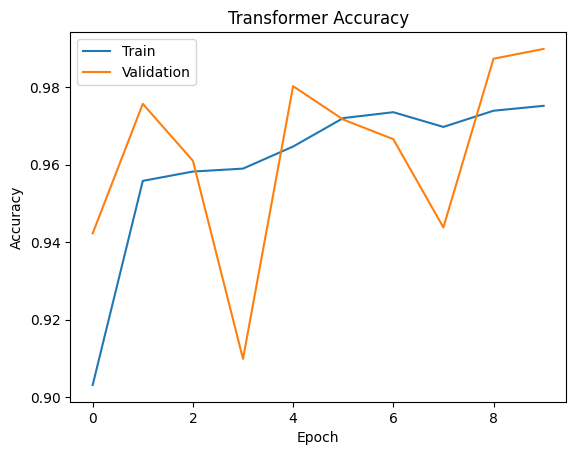

In [53]:
import matplotlib.pyplot as plt

plt.plot(history_small_transformer.history['accuracy'])
plt.plot(history_small_transformer.history['val_accuracy'])
plt.title('Transformer Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

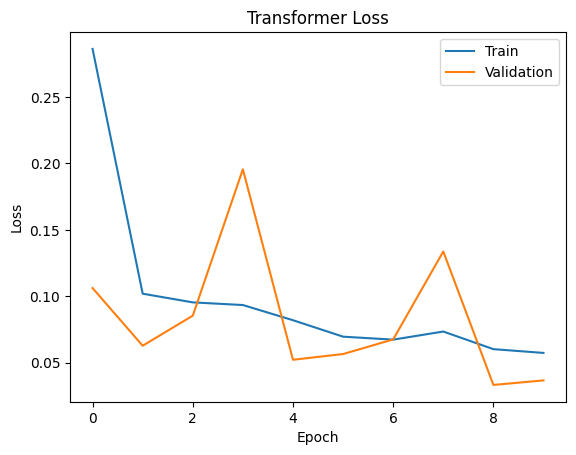

In [54]:
plt.plot(history_small_transformer.history['loss'])
plt.plot(history_small_transformer.history['val_loss'])
plt.title('Transformer Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [56]:
cnn_acc = accuracy_score(y_val, y_pred)
cnn_f1 = f1_score(y_val, y_pred, average='weighted')

trans_acc = accuracy_score(y_val, y_pred_t)
trans_f1 = f1_score(y_val, y_pred_t, average='weighted')

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['CNN', 'Transformer'],
    'Accuracy': [cnn_acc, trans_acc],
    'F1-Score': [cnn_f1, trans_f1]
})

print(comparison)

         Model  Accuracy  F1-Score
0          CNN  0.968608  0.966304
1  Transformer  0.989873  0.989873


In [55]:
cnn_acc = accuracy_score(y_val, y_pred)
cnn_f1 = f1_score(y_val, y_pred, average='weighted')

trans_acc = accuracy_score(y_val, y_pred_t)
trans_f1 = f1_score(y_val, y_pred_t, average='weighted')

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['CNN', 'Transformer'],
    'Accuracy': [cnn_acc, trans_acc],
    'F1-Score': [cnn_f1, trans_f1]
})

print(comparison)

         Model  Accuracy  F1-Score
0          CNN  0.968608  0.966304
1  Transformer  0.989873  0.989873


In [58]:
model.save("cnn_model.keras")
small_transformer_model.save("transformer_model.keras")